[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri

[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri/development_fmri

[fetch_development_fmri] Dataset found in /root/nilearn_data/development_fmri/development_fmri

/root/nilearn_data/development_fmri/development_fmri/sub-pixar123_task-pixar_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz
(50, 59, 50, 168)
(50, 59, 50)


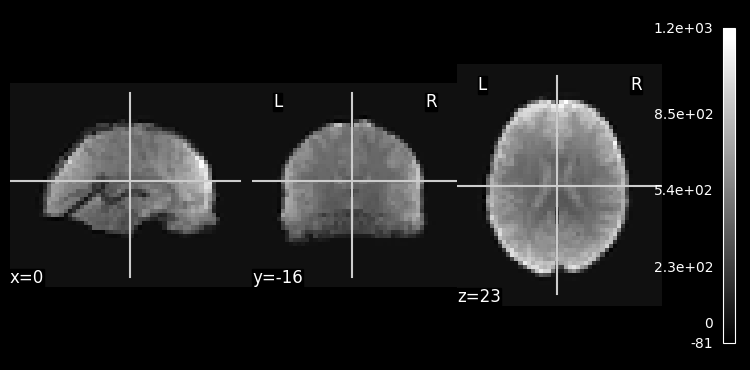

(168,)


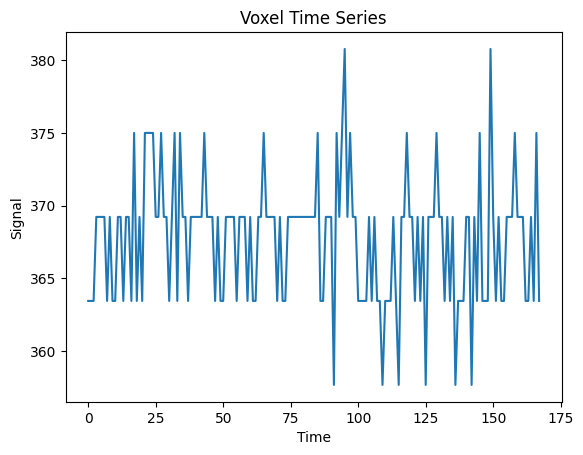

(168, 32504)


In [22]:
from nilearn import datasets

dataset = datasets.fetch_development_fmri(n_subjects=1)

func_file = dataset.func[0]
print(func_file)

from nilearn import image

img = image.load_img(func_file)
print(img.shape)
img_3d = image.index_img(img, 0)
print(img_3d.shape)

from nilearn import plotting

plotting.plot_epi(img_3d)
plotting.show()

import numpy as np

data = img.get_fdata()

# pick one voxel
voxel_ts = data[30, 30, 15, :]

print(voxel_ts.shape)

import matplotlib.pyplot as plt

plt.plot(voxel_ts)
plt.title("Voxel Time Series")
plt.xlabel("Time")
plt.ylabel("Signal")
plt.show()

from nilearn.maskers import NiftiMasker

masker = NiftiMasker(
    standardize="zscore_sample",
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

time_series = masker.fit_transform(func_file)

print(time_series.shape)

In [23]:
from nilearn.datasets import fetch_atlas_harvard_oxford

atlas = fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')

atlas_filename = atlas.maps
labels = atlas.labels


[fetch_atlas_harvard_oxford] Dataset found in /root/nilearn_data/fsl

In [24]:
for i, label in enumerate(labels[:20]):
    print(i, label)

0 Background
1 Frontal Pole
2 Insular Cortex
3 Superior Frontal Gyrus
4 Middle Frontal Gyrus
5 Inferior Frontal Gyrus, pars triangularis
6 Inferior Frontal Gyrus, pars opercularis
7 Precentral Gyrus
8 Temporal Pole
9 Superior Temporal Gyrus, anterior division
10 Superior Temporal Gyrus, posterior division
11 Middle Temporal Gyrus, anterior division
12 Middle Temporal Gyrus, posterior division
13 Middle Temporal Gyrus, temporooccipital part
14 Inferior Temporal Gyrus, anterior division
15 Inferior Temporal Gyrus, posterior division
16 Inferior Temporal Gyrus, temporooccipital part
17 Postcentral Gyrus
18 Superior Parietal Lobule
19 Supramarginal Gyrus, anterior division


In [25]:
for i, label in enumerate(labels):
    if any(keyword in label.lower() for keyword in ["cingulate", "precuneus", "frontal", "parietal"]):
        print(i, label)


1 Frontal Pole
3 Superior Frontal Gyrus
4 Middle Frontal Gyrus
5 Inferior Frontal Gyrus, pars triangularis
6 Inferior Frontal Gyrus, pars opercularis
18 Superior Parietal Lobule
25 Frontal Medial Cortex
28 Paracingulate Gyrus
29 Cingulate Gyrus, anterior division
30 Cingulate Gyrus, posterior division
33 Frontal Orbital Cortex
41 Frontal Opercular Cortex
43 Parietal Opercular Cortex


In [26]:
dmn_indices = [
    1,   # Frontal Pole (proxy mPFC)
    3,   # Superior Frontal Gyrus
    18,  # Superior Parietal Lobule
    19   # Supramarginal Gyrus
]

In [27]:
from nilearn.maskers import NiftiLabelsMasker

labels_masker = NiftiLabelsMasker(
    labels_img=atlas_filename,
    standardize="zscore_sample",
    t_r=2.0
)

roi_time_series = labels_masker.fit_transform(func_file)

In [28]:
dmn_ts = roi_time_series[:, dmn_indices]

print(dmn_ts.shape)


(168, 4)


In [29]:
dmn_indices = [
    1,   # Frontal Pole
    3,   # Superior Frontal Gyrus
    18,  # Superior Parietal Lobule
    19   # Supramarginal Gyrus
]

In [30]:
dmn_ts = roi_time_series[:, dmn_indices]

print(dmn_ts.shape)

(168, 4)


In [31]:
import numpy as np

correlation_matrix = np.corrcoef(dmn_ts.T)

print(correlation_matrix)

[[1.         0.37867561 0.56443607 0.59078207]
 [0.37867561 1.         0.3627855  0.7458518 ]
 [0.56443607 0.3627855  1.         0.72344391]
 [0.59078207 0.7458518  0.72344391 1.        ]]


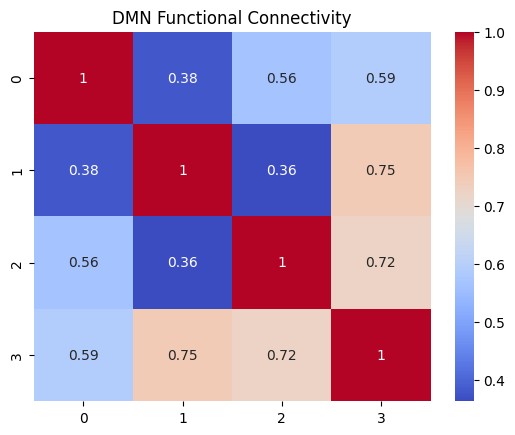

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")
plt.title("DMN Functional Connectivity")
plt.show()

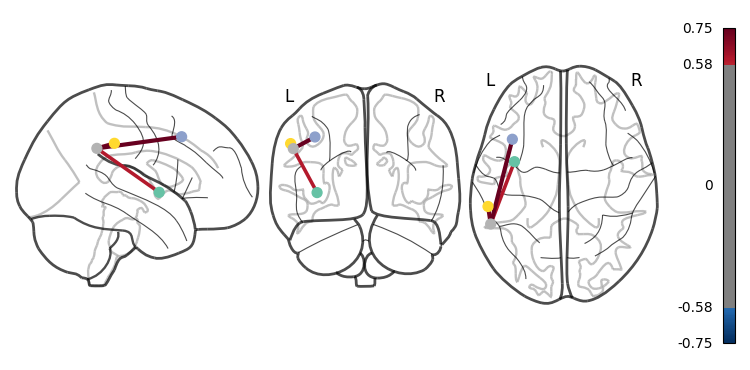

In [33]:
from nilearn import plotting

coords = plotting.find_parcellation_cut_coords(labels_img=atlas_filename)

plotting.plot_connectome(
    correlation_matrix,
    coords[dmn_indices],
    edge_threshold="50%",   # show strongest connections
)

plotting.show()